# YOLO SFP Triangulation Error Viewer

YOLO SFP keypoint prediction을 여러 카메라에서 삼각측량한 뒤 validation label과 비교합니다.

Validation label은 2D이므로, 이 노트북은 label keypoint도 같은 카메라 rig로 3D 재구성하고 prediction 3D와의 유클리드 거리(mm)를 봅니다. 추가로 prediction 3D를 각 카메라에 재투영해서 validation label과의 2D 유클리드 거리(px)도 같이 확인합니다.

또한 `dx/dy/dz = prediction - validation` 축별 signed 오차 분포를 같이 봅니다.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_src_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pixi.toml").exists() and (path / "ais").exists():
            return path
        nested_src = path / "ws_aic" / "src"
        if (nested_src / "pixi.toml").exists() and (nested_src / "ais").exists():
            return nested_src
    raise RuntimeError("ws_aic/src root를 찾지 못했습니다. 노트북을 ws_aic/src 아래에서 실행하세요.")


SRC_ROOT = find_src_root(Path.cwd().resolve())
WS_ROOT = SRC_ROOT.parent
sys.path.insert(0, str(SRC_ROOT / "ais" / "ais_yolo_train"))

from core.triangulation_eval import (  # noqa: E402
    central_coverage_intervals,
    empirical_coverage_thresholds,
    evaluate_validation_triangulation,
)


In [2]:
TARGET = "SFP"
DATASET_DIR = WS_ROOT / "data" / "yolo" / "approach" / TARGET
MODEL_PATH = WS_ROOT / "model" / "ais_yolo" / "approach" / TARGET / "weights" / "best.pt"

SPLIT = "val"
CONF = 0.25
IMGSZ = 640
DEVICE = None  # e.g. 0, "0", "cpu", or None
MAX_EPISODES = None  # quick check: set to 10

print(f"SRC_ROOT: {SRC_ROOT}")
print(f"DATASET_DIR: {DATASET_DIR} exists={DATASET_DIR.exists()}")
print(f"MODEL_PATH: {MODEL_PATH} exists={MODEL_PATH.exists()}")


SRC_ROOT: /home/whyz/aic_sejong/ws_aic/src
DATASET_DIR: /home/whyz/aic_sejong/ws_aic/data/yolo/approach/SFP exists=True
MODEL_PATH: /home/whyz/aic_sejong/ws_aic/model/ais_yolo/approach/SFP/weights/best.pt exists=True


## Run Evaluation

각 episode에서 최소 두 카메라의 prediction과 validation label이 있어야 삼각측량 row가 생성됩니다.


In [3]:
records = evaluate_validation_triangulation(
    dataset_dir=DATASET_DIR,
    model_path=MODEL_PATH,
    target=TARGET,
    split=SPLIT,
    conf=CONF,
    imgsz=IMGSZ,
    device=DEVICE,
    max_episodes=MAX_EPISODES,
)

print(f"evaluation rows: {len(records)}")
if not records:
    raise RuntimeError(
        "No triangulation rows were produced. Check that validation images/labels exist "
        "and at least two cameras have YOLO predictions per episode."
    )

try:
    import pandas as pd
    df = pd.DataFrame(records)
    display(df.head())
except ImportError:
    df = None
    for row in records[:5]:
        print(row)


evaluation rows: 400
{'episode': 'ep00000', 'point': 'port0_top_left', 'target': 'SFP', 'gt_cameras': 'center+left+right', 'pred_cameras': 'center+left+right', 'n_gt_cameras': 3, 'n_pred_cameras': 3, 'dx_m': -0.00017271436004158425, 'dy_m': -0.00016287710152810414, 'dz_m': 0.0016303331069620342, 'dx_mm': -0.17271436004158425, 'dy_mm': -0.16287710152810414, 'dz_mm': 1.6303331069620342, 'error_3d_m': 0.0016475270073729442, 'error_3d_mm': 1.6475270073729442, 'reprojection_error_px_mean': 10.617765310553148, 'reprojection_error_px_max': 12.914339733865798}
{'episode': 'ep00000', 'point': 'port0_top_right', 'target': 'SFP', 'gt_cameras': 'center+left+right', 'pred_cameras': 'center+left+right', 'n_gt_cameras': 3, 'n_pred_cameras': 3, 'dx_m': -0.00019808296033266282, 'dy_m': -0.00021058750166769516, 'dz_m': 0.0013883269558915279, 'dx_mm': -0.19808296033266282, 'dy_mm': -0.21058750166769516, 'dz_mm': 1.3883269558915279, 'error_3d_m': 0.001418109901061208, 'error_3d_mm': 1.418109901061208, 're

## Error Summary

90%, 95%, 99% 구간은 empirical coverage interval `[0, quantile]`로 계산합니다.


In [4]:
def values_for(column: str) -> np.ndarray:
    return np.array([float(row[column]) for row in records], dtype=np.float64)


def print_summary(column: str, label: str) -> dict[float, float]:
    values = values_for(column)
    thresholds = empirical_coverage_thresholds(values)
    print(f"\n{label}")
    print(f"  n      : {values.size}")
    print(f"  mean   : {values.mean():.4f}")
    print(f"  median : {np.median(values):.4f}")
    print(f"  max    : {values.max():.4f}")
    for coverage, threshold in thresholds.items():
        print(f"  {coverage:.0%} coverage interval: [0, {threshold:.4f}]")
    return thresholds


def print_axis_summary(column: str, label: str):
    values = values_for(column)
    intervals = central_coverage_intervals(values)
    abs_thresholds = empirical_coverage_thresholds(np.abs(values))
    print(f"\n{label} signed axis error (mm, pred - gt)")
    print(f"  n      : {values.size}")
    print(f"  mean   : {values.mean():+.4f}")
    print(f"  median : {np.median(values):+.4f}")
    print(f"  std    : {values.std(ddof=0):.4f}")
    print(f"  min/max: {values.min():+.4f} / {values.max():+.4f}")
    for coverage, (lo, hi) in intervals.items():
        abs_limit = abs_thresholds[coverage]
        print(f"  {coverage:.0%} central interval: [{lo:+.4f}, {hi:+.4f}]   |{label}| <= {abs_limit:.4f}")
    return intervals, abs_thresholds

error_specs = [
    ("error_3d_mm", "3D Euclidean error: triangulated prediction vs validation-label triangulation (mm)"),
    ("reprojection_error_px_mean", "2D Euclidean error: reprojected triangulation vs validation label, mean over cameras (px)"),
]
axis_specs = [
    ("dx_mm", "dx"),
    ("dy_mm", "dy"),
    ("dz_mm", "dz"),
]

all_thresholds = {column: print_summary(column, label) for column, label in error_specs}
axis_intervals = {}
axis_abs_thresholds = {}
for column, label in axis_specs:
    intervals, abs_thresholds = print_axis_summary(column, label)
    axis_intervals[column] = intervals
    axis_abs_thresholds[column] = abs_thresholds



3D Euclidean error: triangulated prediction vs validation-label triangulation (mm)
  n      : 400
  mean   : 2.3442
  median : 2.1992
  max    : 7.7936
  90% coverage interval: [0, 3.8274]
  95% coverage interval: [0, 4.1734]
  99% coverage interval: [0, 5.7831]

2D Euclidean error: reprojected triangulation vs validation label, mean over cameras (px)
  n      : 400
  mean   : 12.1021
  median : 10.5384
  max    : 31.4677
  90% coverage interval: [0, 21.9675]
  95% coverage interval: [0, 23.6681]
  99% coverage interval: [0, 30.7801]

dx signed axis error (mm, pred - gt)
  n      : 400
  mean   : -0.3158
  median : -0.2618
  std    : 0.3797
  min/max: -1.5831 / +1.1156
  90% central interval: [-1.0452, +0.1731]   |dx| <= 0.8704
  95% central interval: [-1.1823, +0.3520]   |dx| <= 1.0552
  99% central interval: [-1.4305, +1.0263]   |dx| <= 1.3366

dy signed axis error (mm, pred - gt)
  n      : 400
  mean   : -0.0778
  median : -0.0439
  std    : 0.4751
  min/max: -3.1265 / +1.8250
  9

## Distribution And Coverage

히스토그램과 ECDF에 90%, 95%, 99% coverage threshold를 각각 표시합니다.


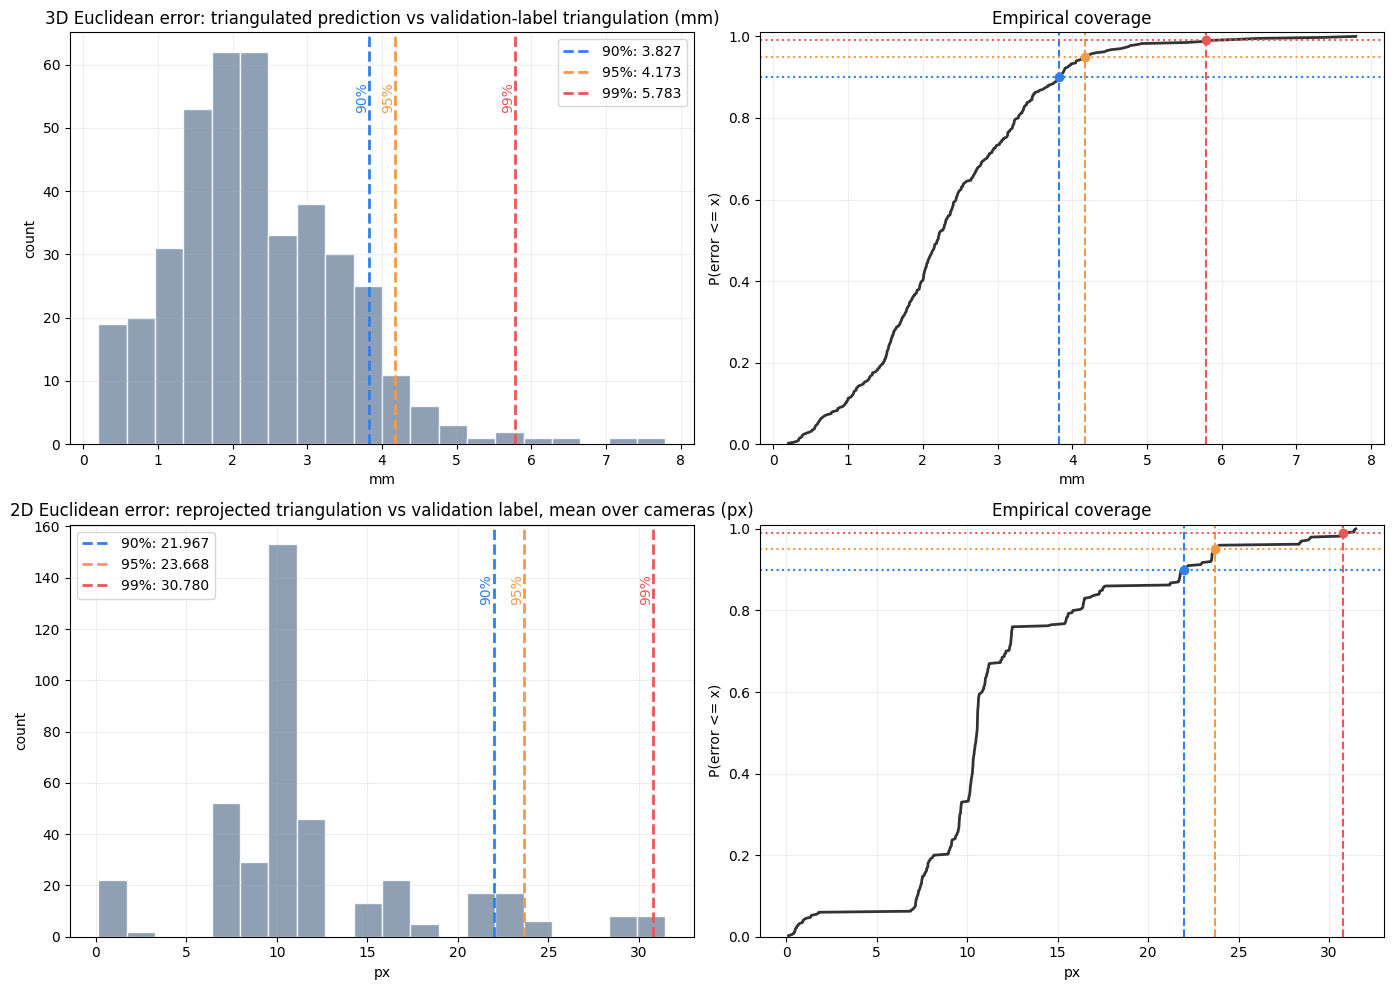

In [5]:
COLORS = {0.90: "#2f80ed", 0.95: "#f2994a", 0.99: "#eb5757"}


def plot_distribution(column: str, label: str, unit: str, axes):
    values = np.sort(values_for(column))
    thresholds = all_thresholds[column]

    ax_hist, ax_ecdf = axes
    bins = min(40, max(8, int(np.sqrt(values.size))))
    ax_hist.hist(values, bins=bins, color="#7b8fa8", edgecolor="white", alpha=0.85)
    ax_hist.set_title(label)
    ax_hist.set_xlabel(unit)
    ax_hist.set_ylabel("count")
    ax_hist.grid(alpha=0.2)

    y_top = ax_hist.get_ylim()[1]
    for coverage, threshold in thresholds.items():
        color = COLORS[coverage]
        ax_hist.axvline(threshold, color=color, linestyle="--", linewidth=2, label=f"{coverage:.0%}: {threshold:.3f}")
        ax_hist.text(threshold, y_top * 0.88, f"{coverage:.0%}", rotation=90, va="top", ha="right", color=color)
    ax_hist.legend()

    y = np.arange(1, values.size + 1) / values.size
    ax_ecdf.plot(values, y, color="#333333", linewidth=2)
    for coverage, threshold in thresholds.items():
        color = COLORS[coverage]
        ax_ecdf.axhline(coverage, color=color, linestyle=":", linewidth=1.5)
        ax_ecdf.axvline(threshold, color=color, linestyle="--", linewidth=1.5)
        ax_ecdf.scatter([threshold], [coverage], color=color, zorder=3)
    ax_ecdf.set_title("Empirical coverage")
    ax_ecdf.set_xlabel(unit)
    ax_ecdf.set_ylabel("P(error <= x)")
    ax_ecdf.set_ylim(0.0, 1.01)
    ax_ecdf.grid(alpha=0.2)


fig, axes = plt.subplots(len(error_specs), 2, figsize=(14, 5 * len(error_specs)))
if len(error_specs) == 1:
    axes = np.array([axes])

for row_idx, (column, label) in enumerate(error_specs):
    unit = "mm" if column.endswith("_mm") else "px"
    plot_distribution(column, label, unit, axes[row_idx])

fig.tight_layout()
plt.show()


## Axis Error Distribution

`dx/dy/dz = predicted triangulated 3D - validation-label triangulated 3D` 입니다. 왼쪽은 signed 분포와 central interval, 오른쪽은 절대축오차의 empirical coverage입니다.


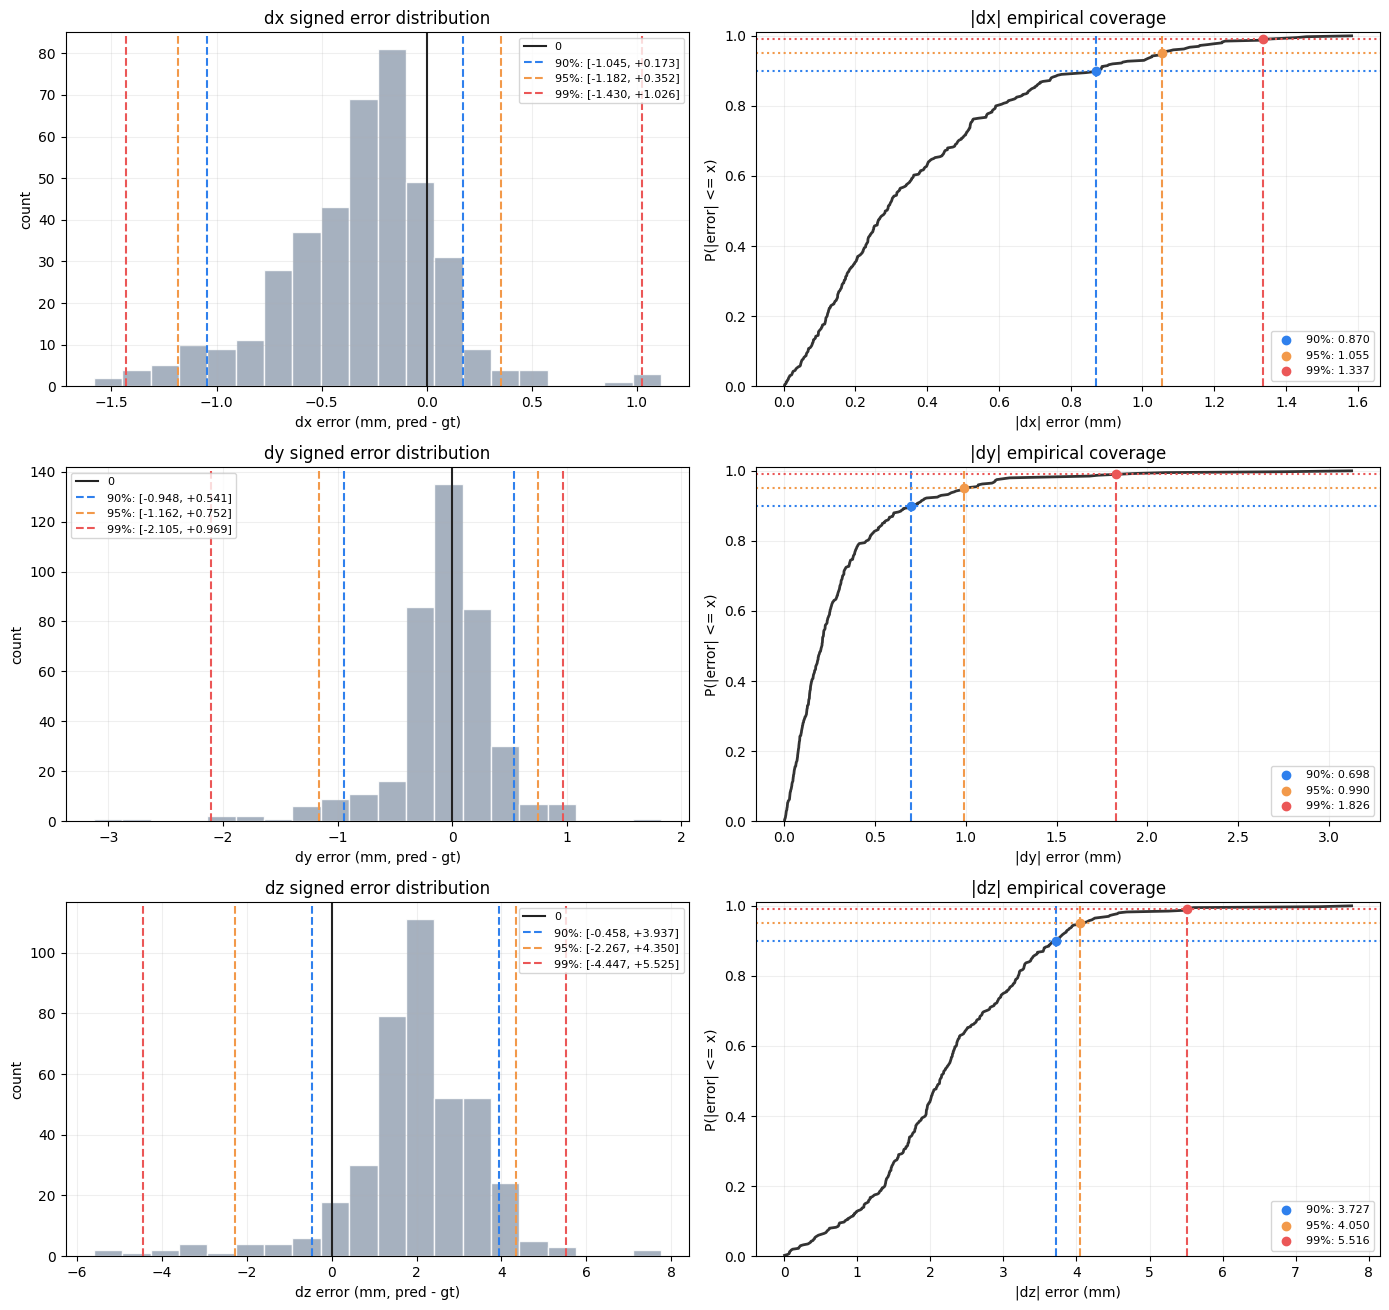

In [6]:
fig, axes = plt.subplots(len(axis_specs), 2, figsize=(14, 4.4 * len(axis_specs)))
if len(axis_specs) == 1:
    axes = np.array([axes])

for row_idx, (column, label) in enumerate(axis_specs):
    values = values_for(column)
    sorted_abs = np.sort(np.abs(values))
    y_abs = np.arange(1, sorted_abs.size + 1) / sorted_abs.size

    ax_hist, ax_ecdf = axes[row_idx]
    bins = min(40, max(8, int(np.sqrt(values.size))))
    ax_hist.hist(values, bins=bins, color="#9aa7b6", edgecolor="white", alpha=0.88)
    ax_hist.axvline(0.0, color="#222222", linewidth=1.5, label="0")
    for coverage, (lo, hi) in axis_intervals[column].items():
        color = COLORS[coverage]
        ax_hist.axvline(lo, color=color, linestyle="--", linewidth=1.5)
        ax_hist.axvline(hi, color=color, linestyle="--", linewidth=1.5, label=f"{coverage:.0%}: [{lo:+.3f}, {hi:+.3f}]")
    ax_hist.set_title(f"{label} signed error distribution")
    ax_hist.set_xlabel(f"{label} error (mm, pred - gt)")
    ax_hist.set_ylabel("count")
    ax_hist.grid(alpha=0.2)
    ax_hist.legend(fontsize=8)

    ax_ecdf.plot(sorted_abs, y_abs, color="#333333", linewidth=2)
    for coverage, threshold in axis_abs_thresholds[column].items():
        color = COLORS[coverage]
        ax_ecdf.axhline(coverage, color=color, linestyle=":", linewidth=1.5)
        ax_ecdf.axvline(threshold, color=color, linestyle="--", linewidth=1.5)
        ax_ecdf.scatter([threshold], [coverage], color=color, zorder=3, label=f"{coverage:.0%}: {threshold:.3f}")
    ax_ecdf.set_title(f"|{label}| empirical coverage")
    ax_ecdf.set_xlabel(f"|{label}| error (mm)")
    ax_ecdf.set_ylabel("P(|error| <= x)")
    ax_ecdf.set_ylim(0.0, 1.01)
    ax_ecdf.grid(alpha=0.2)
    ax_ecdf.legend(fontsize=8)

fig.tight_layout()
plt.show()


## Per-Point Breakdown


/tmp/ipykernel_653275/106184305.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values_by_point, labels=points, showfliers=True)


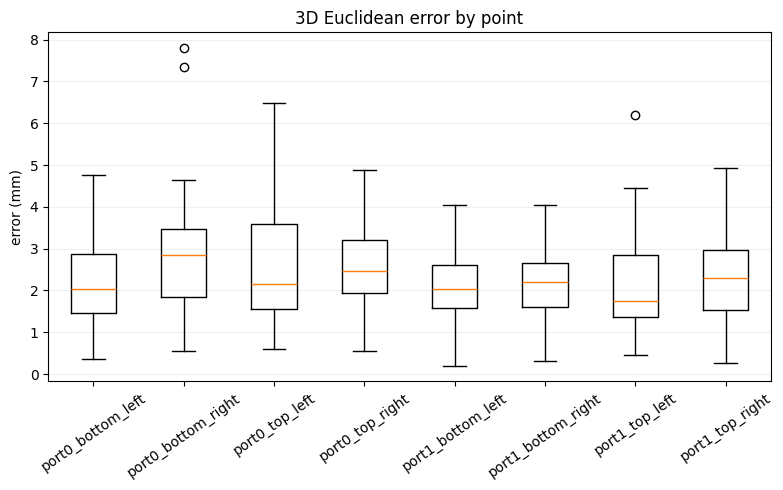

In [7]:
points = sorted({row["point"] for row in records})
values_by_point = [[row["error_3d_mm"] for row in records if row["point"] == point] for point in points]

fig_width = max(8, len(points) * 0.9)
fig, ax = plt.subplots(1, 1, figsize=(fig_width, 5))
ax.boxplot(values_by_point, labels=points, showfliers=True)
ax.set_title("3D Euclidean error by point")
ax.set_ylabel("error (mm)")
ax.grid(axis="y", alpha=0.2)
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()


## Worst Cases


In [ ]:
worst = sorted(records, key=lambda row: row["error_3d_mm"], reverse=True)[:20]
if df is not None:
    display(df.sort_values("error_3d_mm", ascending=False).head(20))
else:
    for row in worst:
        print(row)


{'episode': 'ep00350', 'point': 'port0_bottom_right', 'target': 'SFP', 'gt_cameras': 'center+left+right', 'pred_cameras': 'center+left+right', 'n_gt_cameras': 3, 'n_pred_cameras': 3, 'dx_m': 0.0005193121016310864, 'dy_m': -0.00039927792273183535, 'dz_m': 0.007765997728226948, 'dx_mm': 0.5193121016310864, 'dy_mm': -0.3992779227318354, 'dz_mm': 7.765997728226948, 'error_3d_m': 0.007793576113268392, 'error_3d_mm': 7.793576113268392, 'reprojection_error_px_mean': 14.655218457065638, 'reprojection_error_px_max': 22.56868598224864}
{'episode': 'ep00340', 'point': 'port0_bottom_right', 'target': 'SFP', 'gt_cameras': 'center+left+right', 'pred_cameras': 'center+left+right', 'n_gt_cameras': 3, 'n_pred_cameras': 3, 'dx_m': 0.000543978116666774, 'dy_m': -0.00030605248175645874, 'dz_m': 0.0073089723472863355, 'dx_mm': 0.543978116666774, 'dy_mm': -0.3060524817564587, 'dz_mm': 7.3089723472863355, 'error_3d_m': 0.007335574761830046, 'error_3d_mm': 7.335574761830046, 'reprojection_error_px_mean': 14.4

: 